<a href="https://colab.research.google.com/github/adaryass/Financial-applications-with-Python/blob/main/CAPM_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [4]:
today_date = datetime.today()
year_prior = today_date - timedelta(weeks = 52)
str_today = today_date.strftime("%Y-%m-%d")
str_year_prior = year_prior.strftime("%Y-%m-%d")

print("Date d'aujourd'hui : ", str_today)
print("Date il y a un an : ", str_year_prior)

Date d'aujourd'hui :  2026-03-14
Date il y a un an :  2025-03-15


In [6]:
list_tickers = ['MSFT', 'AAPL', 'GOOG']
prices = pd.DataFrame()

for i in list_tickers:
    try:
        data = yf.download(i, start= str_year_prior, end= str_today)
        prices[i] = data['Close']
    except:
        continue

prices.head()

/tmp/ipykernel_226/1846341536.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start= str_year_prior, end= str_today)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_226/1846341536.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start= str_year_prior, end= str_today)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_226/1846341536.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start= str_year_prior, end= str_today)
[*********************100%***********************]  1 of 1 completed


,MSFT,AAPL,GOOG
Date,,,
2025-03-17,385.746887,213.071350,165.996155
2025-03-18,380.606232,211.767014,162.109573
2025-03-19,384.873566,214.305954,165.707138
2025-03-20,383.901031,213.170914,164.481384
2025-03-21,388.287445,217.322800,165.677231


<function matplotlib.pyplot.show(close=None, block=None)>

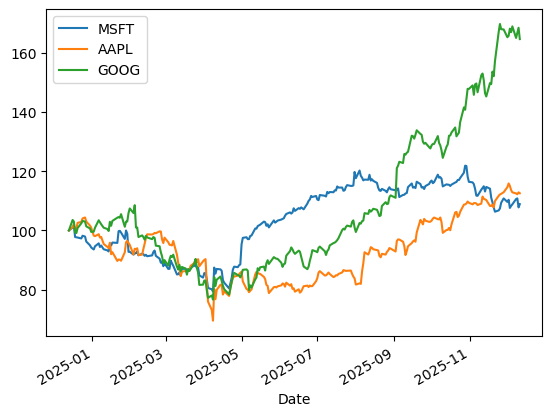

In [ ]:
# Affiche l’évolution de prices normalisée à 100 au départ, ce qui permet de visualiser la performance relative dans le temps.
(prices/prices.iloc[0] * 100).plot()
plt.show

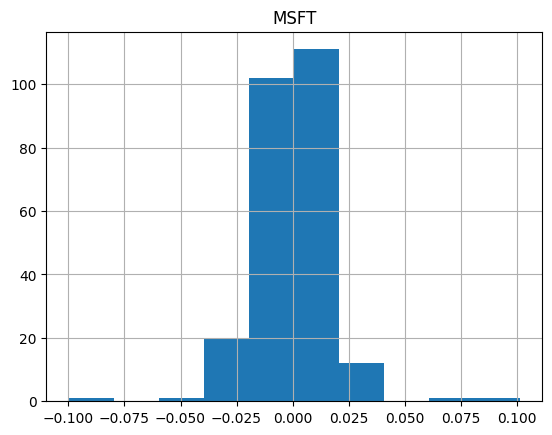

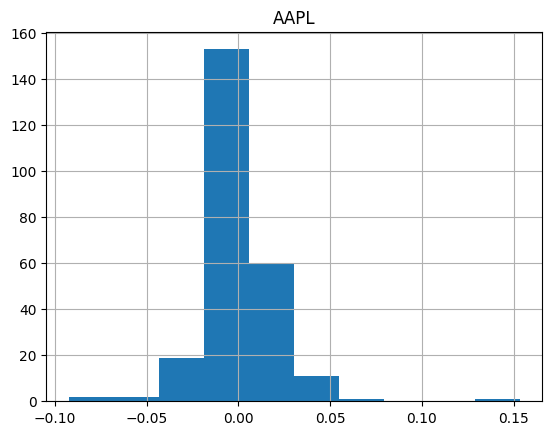

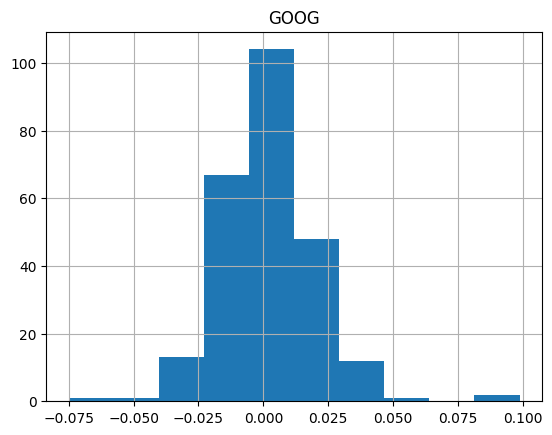

In [9]:
returns = prices.pct_change().dropna(axis= 0)
for i in returns:
    plt_data = returns[i]
    plt_data.hist()
    plt.title(i)
    plt.show()

In [11]:
mean_returns = returns.mean()
correlation = returns.corr()
stdev = returns.std()
stdev

,0
MSFT,0.016537
AAPL,0.020060
GOOG,0.019029


In [13]:
correlation

,MSFT,AAPL,GOOG
MSFT,1.000000,0.395246,0.327175
AAPL,0.395246,1.000000,0.498767
GOOG,0.327175,0.498767,1.000000


In [14]:
returns.describe()

,MSFT,AAPL,GOOG
count,249.000000,249.000000,249.000000
mean,0.000237,0.000842,0.002578
std,0.016537,0.020060,0.019029
min,-0.099931,-0.092456,-0.075060
25%,-0.006719,-0.006467,-0.008674
50%,0.000780,0.000786,0.002072
75%,0.006510,0.006336,0.012273
max,0.101337,0.153288,0.098786


In [20]:
#3 months t bill
rf = pd.read_excel("/content/DTB3.xlsx", sheet_name="Daily", index_col='observation_date') / 100
#SP500 price series
spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close'].ffill()

/tmp/ipykernel_226/199626318.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close'].ffill()
[*********************100%***********************]  1 of 1 completed


In [21]:
rf.head()

,DTB3
observation_date,
2016-03-14,0.0034
2016-03-15,0.0034
2016-03-16,0.0031
2016-03-17,0.0029
2016-03-18,0.0029


In [32]:
# Calculer le rendement journalier de la série de prix du SP500
returns_spx = spx.pct_change()

# Utiliser display pour vérifier les données
#display(returns_spx)

# Sur la série de rendements, nous ajoutons une colonne contenant la série de taux sans risque
returns_spx['rf'] = rf/252  # On divise par 252 pour obtenir les valeurs journalières

returns_spx = returns_spx.dropna(axis = 0)  # On nettoie les données pour supprimer les lignes vides
                                           # Supprime les lignes contenant des NaN.

# Calcul du rendement excédentaire
returns_spx['excess returns'] = returns_spx['^SPX'] - returns_spx['rf']

# Prime de marché annuelle du SP500
mkt_premium = returns_spx['excess returns'].mean()*252

print(returns_spx.head())
print()
print("La prime de marché annuelle du SP500 : ", mkt_premium *100)

Ticker          ^SPX        rf  excess returns
Date                                          
2025-03-18 -0.010654  0.000167       -0.010820
2025-03-19  0.010798  0.000167        0.010632
2025-03-20 -0.002185  0.000166       -0.002351
2025-03-21  0.000825  0.000166        0.000658
2025-03-24  0.017646  0.000166        0.017480

La prime de marché annuelle du SP500 :  12.481713831046875


In [34]:
# Fonction de calcul de la rentabilité attendue selon le CAPM
def capm(rf, beta, mkt):
    return rf+beta*mkt

In [35]:
#Prices to series
aapl_prices = yf.download("AAPL", start = str_year_prior, end = str_today)['Close']
aapl_returns = aapl_prices.pct_change()
aapl_returns['rf'] = rf/252
aapl_returns.dropna(axis=0, inplace=True)
#computing apple's excess returns
aapl_excess_returns = aapl_returns['AAPL'] - aapl_returns['rf']

/tmp/ipykernel_226/2629142649.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_prices = yf.download("AAPL", start = str_year_prior, end = str_today)['Close']
[*********************100%***********************]  1 of 1 completed


In [36]:
print(aapl_returns)

Ticker          AAPL        rf
Date                          
2025-03-18 -0.006122  0.000167
2025-03-19  0.011989  0.000167
2025-03-20 -0.005296  0.000166
2025-03-21  0.019477  0.000166
2025-03-24  0.011271  0.000166
...              ...       ...
2026-03-06 -0.010873  0.000142
2026-03-09  0.009400  0.000143
2026-03-10  0.003655  0.000143
2026-03-11 -0.000077  0.000143
2026-03-12 -0.019363  0.000143

[246 rows x 2 columns]


In [37]:
print(aapl_excess_returns)

Date
2025-03-18   -0.006288
2025-03-19    0.011823
2025-03-20   -0.005463
2025-03-21    0.019311
2025-03-24    0.011104
                ...   
2026-03-06   -0.011015
2026-03-09    0.009256
2026-03-10    0.003513
2026-03-11   -0.000220
2026-03-12   -0.019506
Length: 246, dtype: float64


###### A installer :
pip install statsmodels

In [38]:
pip install statsmodels

In [39]:
import statsmodels.api as sm

In [40]:
y = aapl_excess_returns
x = returns_spx['excess returns']
print(len(aapl_excess_returns), len(returns_spx))

246 246


In [41]:
# Regression
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     342.9
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.09e-48
Time:                        14:44:12   Log-Likelihood:                 720.81
No. Observations:                 246   AIC:                            -1438.
Df Residuals:                     244   BIC:                            -1431.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -6.427e-06      0.001     -0.

In [42]:
#BETA
aapl_beta = model.params['excess returns']
print(aapl_beta)

1.340754084698983


In [43]:
mkt_premium
risk_free = rf.mean()

In [ ]:
mkt_premium

np.float64(0.11077532536193474)

In [44]:
print(risk_free)

DTB3    0.022391
dtype: float64


In [45]:
aapl_capm = capm(risk_free, aapl_beta, mkt_premium)
print(aapl_capm)

DTB3    0.18974
dtype: float64


### Partie 2 CAPM

In [60]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [46]:
# Il ne nous reste plus que le beta à estimer
def capm(rf, beta, mkt):
    return rf + beta*mkt

In [47]:
#3 months t bill
rf = pd.read_excel("/content/DTB3.xlsx", sheet_name="Daily", index_col='observation_date') / 100
#SP500 price series
spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close'].ffill()

/tmp/ipykernel_226/199626318.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close'].ffill()
[*********************100%***********************]  1 of 1 completed


In [51]:
# Calculer le rendement journalier de la série de prix du SP500
returns_spx = spx.pct_change()

# Utiliser display pour vérifier les données
#display(returns_spx)

# Sur la série de rendements, on ajoute une colonne contenant la série du taux sans risque
returns_spx['rf'] = rf/252 # On divise par 252 pour obtenir des valeurs journalières

returns_spx = returns_spx.dropna(axis = 0) # On nettoie les données pour supprimer les lignes vides
                                           # Supprime les lignes contenant des NaN.

returns_spx['excess returns'] = returns_spx['^SPX'] - returns_spx['rf'] # Calcul du rendement excédentaire

print(returns_spx)

mkt_premium = returns_spx['excess returns'].mean()*252 # Prime de marché annuelle du SP500
print()
print("La prime de marché annuelle du SP500 : ",mkt_premium *100)

Ticker          ^SPX        rf  excess returns
Date                                          
2025-03-18 -0.010654  0.000167       -0.010820
2025-03-19  0.010798  0.000167        0.010632
2025-03-20 -0.002185  0.000166       -0.002351
2025-03-21  0.000825  0.000166        0.000658
2025-03-24  0.017646  0.000166        0.017480
...              ...       ...             ...
2026-03-06 -0.013277  0.000142       -0.013419
2026-03-09  0.008304  0.000143        0.008161
2026-03-10 -0.002135  0.000143       -0.002278
2026-03-11 -0.000838  0.000143       -0.000981
2026-03-12 -0.015228  0.000143       -0.015371

[246 rows x 3 columns]

La prime de marché annuelle du SP500 :  12.481713831046875


In [56]:
aapl_returns = aapl_prices.pct_change().dropna()
aapl_returns['rf'] = rf/252
aapl_returns = aapl_returns.dropna(axis = 0)
aapl_returns['excess returns AAPL'] = aapl_returns['AAPL'] - aapl_returns['rf']
print(aapl_returns)

Ticker          AAPL        rf  excess returns AAPL
Date                                               
2025-03-18 -0.006122  0.000167            -0.006288
2025-03-19  0.011989  0.000167             0.011823
2025-03-20 -0.005296  0.000166            -0.005463
2025-03-21  0.019477  0.000166             0.019311
2025-03-24  0.011271  0.000166             0.011104
...              ...       ...                  ...
2026-03-06 -0.010873  0.000142            -0.011015
2026-03-09  0.009400  0.000143             0.009256
2026-03-10  0.003655  0.000143             0.003513
2026-03-11 -0.000077  0.000143            -0.000220
2026-03-12 -0.019363  0.000143            -0.019506

[246 rows x 3 columns]


In [57]:
df = pd.concat([aapl_returns, returns_spx['excess returns']], axis=1).dropna()
print(df)

                AAPL        rf  excess returns AAPL  excess returns
Date                                                               
2025-03-18 -0.006122  0.000167            -0.006288       -0.010820
2025-03-19  0.011989  0.000167             0.011823        0.010632
2025-03-20 -0.005296  0.000166            -0.005463       -0.002351
2025-03-21  0.019477  0.000166             0.019311        0.000658
2025-03-24  0.011271  0.000166             0.011104        0.017480
...              ...       ...                  ...             ...
2026-03-06 -0.010873  0.000142            -0.011015       -0.013419
2026-03-09  0.009400  0.000143             0.009256        0.008161
2026-03-10  0.003655  0.000143             0.003513       -0.002278
2026-03-11 -0.000077  0.000143            -0.000220       -0.000981
2026-03-12 -0.019363  0.000143            -0.019506       -0.015371

[246 rows x 4 columns]


In [58]:
y = aapl_returns # Rendement de mon action Apple
X = returns_spx['excess returns']
print(len(aapl_returns), len(returns_spx))
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()

print(aapl_returns)
print(returns_spx)

246 246
Ticker          AAPL        rf  excess returns AAPL
Date                                               
2025-03-18 -0.006122  0.000167            -0.006288
2025-03-19  0.011989  0.000167             0.011823
2025-03-20 -0.005296  0.000166            -0.005463
2025-03-21  0.019477  0.000166             0.019311
2025-03-24  0.011271  0.000166             0.011104
...              ...       ...                  ...
2026-03-06 -0.010873  0.000142            -0.011015
2026-03-09  0.009400  0.000143             0.009256
2026-03-10  0.003655  0.000143             0.003513
2026-03-11 -0.000077  0.000143            -0.000220
2026-03-12 -0.019363  0.000143            -0.019506

[246 rows x 3 columns]
Ticker          ^SPX        rf  excess returns
Date                                          
2025-03-18 -0.010654  0.000167       -0.010820
2025-03-19  0.010798  0.000167        0.010632
2025-03-20 -0.002185  0.000166       -0.002351
2025-03-21  0.000825  0.000166        0.000658
2025-03-24

In [61]:
TSLA = yf.download("TSLA", start= str_year_prior, end = str_today)['Close']
# Calcul the returns
tsla_returns= TSLA.pct_change().dropna()
print('rentabilité  simple: ',tsla_returns)
print()
tsla_logreturns = np.log(TSLA/TSLA.shift(1)).dropna()
print('rentabilité logarithmique:', tsla_logreturns)

/tmp/ipykernel_226/225421684.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  TSLA = yf.download("TSLA", start= str_year_prior, end = str_today)['Close']
[*********************100%***********************]  1 of 1 completed

rentabilité  simple:  Ticker          TSLA
Date                
2025-03-18 -0.053359
2025-03-19  0.046824
2025-03-20  0.001696
2025-03-21  0.052696
2025-03-24  0.119336
...              ...
2026-03-09  0.004915
2026-03-10  0.001405
2026-03-11  0.021491
2026-03-12 -0.031411
2026-03-13 -0.009645

[249 rows x 1 columns]

rentabilité logarithmique: Ticker          TSLA
Date                
2025-03-18 -0.054835
2025-03-19  0.045761
2025-03-20  0.001694
2025-03-21  0.051355
2025-03-24  0.112735
...              ...
2026-03-09  0.004903
2026-03-10  0.001404
2026-03-11  0.021263
2026-03-12 -0.031915
2026-03-13 -0.009692

[249 rows x 1 columns]


In [64]:
spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close']
spx_returns = spx.pct_change().dropna()
spx_logreturns = np.log(spx/spx.shift(1)).dropna()

/tmp/ipykernel_226/1600436817.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close']
[*********************100%***********************]  1 of 1 completed


In [65]:
rf = 0.03
rf_daily = (1 + rf)**(1/252) - 1 # Transformer les données annuels en données deely

excess_spx_returns = spx_logreturns - rf_daily
excess_tsla_returns = tsla_logreturns - rf_daily

In [66]:
# Align log-returns and run OLS regression (TSLA on SPX)
data_tsla_spx = pd.concat([
    excess_tsla_returns['TSLA'].rename('TSLA'),
    excess_spx_returns['^SPX'].rename('SPX')
], axis=1).dropna()

data_tsla_spx

,TSLA,SPX
Date,,
2025-03-18,-0.054953,-0.010828
2025-03-19,0.045644,0.010623
2025-03-20,0.001577,-0.002305
2025-03-21,0.051237,0.000707
2025-03-24,0.112618,0.017375
...,...,...
2026-03-09,0.004786,0.008153
2026-03-10,0.001286,-0.002255
2026-03-11,0.021146,-0.000955


In [67]:
X = sm.add_constant(data_tsla_spx['SPX'])
y = data_tsla_spx['TSLA']

results_tsla = sm.OLS(y, X).fit()
results_tsla.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   TSLA   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     216.8
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.19e-35
Time:                        15:14:46   Log-Likelihood:                 554.80
No. Observations:                 249   AIC:                            -1106.
Df Residuals:                     247   BIC:                            -1099.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.002      0.471      0.638      -0.002       0.004
SPX            2.1555      0.146     14.724      0.000       1.867       2.444
==============================================================================
Omnibus:                       36.728   Durbin-Watson:                   1.944
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              138.718
Skew:                          -0.518   Prob(JB):                     7.55e-31
Kurtosis:                       6.507   Cond. No.                         88.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [68]:
print("Estimated beta (TSLA vs SPX):", results_tsla.params['SPX'])
print("Alpha (intercept):", results_tsla.params['const'])
print("\n95% CI for beta:\n", results_tsla.conf_int().loc['SPX'])
print("\nRegression summary:\n", results_tsla.summary())

Estimated beta (TSLA vs SPX): 2.1555136411076545
Alpha (intercept): 0.0007820676584283336

95% CI for beta:
 0    1.867172
1    2.443856
Name: SPX, dtype: float64

Regression summary:
                             OLS Regression Results                            
Dep. Variable:                   TSLA   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     216.8
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.19e-35
Time:                        15:15:30   Log-Likelihood:                 554.80
No. Observations:                 249   AIC:                            -1106.
Df Residuals:                     247   BIC:                            -1099.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    

In [ ]:
beta = results_tsla.params['SPX']
print("Estimated beta (TSLA vs SPX):", beta)

Estimated beta (TSLA vs SPX): 2.3556152498052745


In [ ]:
# optional diagnostics
se_beta = results_tsla.bse['SPX']
t_beta = results_tsla.tvalues['SPX']
p_beta = results_tsla.pvalues['SPX']
ci_beta = results_tsla.conf_int().loc['SPX']
print("SE:", se_beta, "t-stat:", t_beta, "p-value:", p_beta)
print("\n")
print("95% CI for beta:")
print(ci_beta)

SE: 0.15729602006474225 t-stat: 14.97568246695444 p-value: 1.7827924421149175e-36


95% CI for beta:
0    2.045796
1    2.665434
Name: SPX, dtype: float64


In [69]:
# CAPM
mft = spx_logreturns.mean() * 252
print("Market risk premium (annualized):", mft - rf)
def capm(rf, beta, mft):
    mkt = mft - rf
    return rf + beta*mkt

Market risk premium (annualized): Ticker
^SPX    0.127721
dtype: float64


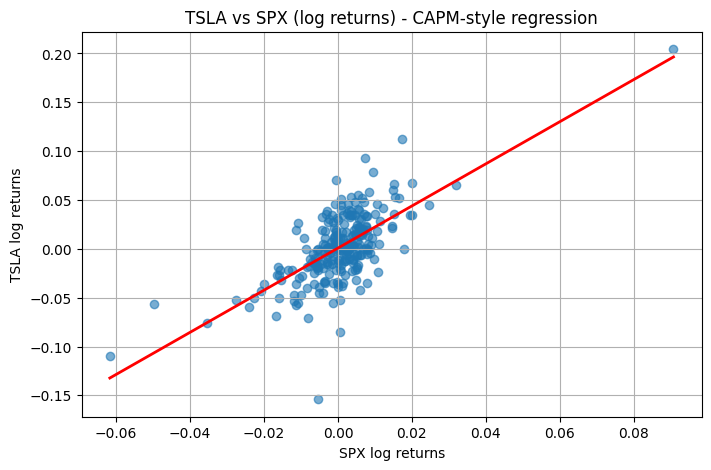

In [70]:
# Scatter + fitted line
plt.figure(figsize=(8,5))
plt.scatter(data_tsla_spx['SPX'], data_tsla_spx['TSLA'], alpha=0.6)
x_vals = np.linspace(data_tsla_spx['SPX'].min(), data_tsla_spx['SPX'].max(), 100)
y_pred = results_tsla.params['const'] + results_tsla.params['SPX'] * x_vals
plt.plot(x_vals, y_pred, color='red', linewidth=2)
plt.xlabel('SPX log returns')
plt.ylabel('TSLA log returns')
plt.title('TSLA vs SPX (log returns) - CAPM-style regression')
plt.grid(True)
plt.show()

Estimated beta: 1.340754084698983
Alpha (intercept): -6.427360917377918e-06

95% confidence interval for beta:
 0    1.198134
1    1.483374
Name: MKT_excess, dtype: float64

Regression summary:
                             OLS Regression Results                            
Dep. Variable:            AAPL_excess   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     342.9
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.09e-48
Time:                        16:06:21   Log-Likelihood:                 720.81
No. Observations:                 246   AIC:                            -1438.
Df Residuals:                     244   BIC:                            -1431.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
               

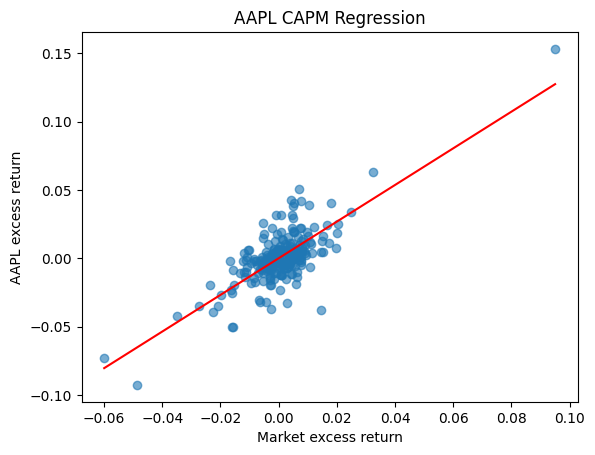

In [73]:
# Préparer les données : aligner les dates et utiliser les rendements excédentaires
data = pd.concat([
    aapl_returns['excess returns AAPL'].rename('AAPL_excess'),
    returns_spx['excess returns'].rename('MKT_excess')
], axis=1).dropna()

# Régression (le beta du CAPM = la pente de la régression des rendements excédentaires d’AAPL sur ceux du marché)
X = sm.add_constant(data['MKT_excess'])
y = data['AAPL_excess']
model = sm.OLS(y, X).fit()

# Afficher les résultats
print("Estimated beta:", model.params['MKT_excess'])
print("Alpha (intercept):", model.params['const'])
print("\n95% confidence interval for beta:\n", model.conf_int().loc['MKT_excess'])
print("\nRegression summary:\n", model.summary())

# Optionnel : nuage de points + droite de régression estimée
plt.scatter(data['MKT_excess'], data['AAPL_excess'], alpha=0.6)
mkt_vals = np.linspace(data['MKT_excess'].min(), data['MKT_excess'].max(), 100)
pred_line = model.params['const'] + model.params['MKT_excess'] * mkt_vals
plt.plot(mkt_vals, pred_line, color='red')
plt.xlabel('Market excess return')
plt.ylabel('AAPL excess return')
plt.title('AAPL CAPM Regression')
plt.show()

#### Partie 3

In [74]:
list_tickers = ['MSFT', 'AAPL', 'GOOG']
prices = pd.DataFrame()
for i in list_tickers:
    try:
        data = yf.download(i, start = str_year_prior, end = str_today)
        prices[i] = data['Close']
    except:
        continue
rf=pd.read_excel("/content/DTB3.xlsx", sheet_name="Daily", index_col='observation_date') / 100
# SP500 prices
spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close']

/tmp/ipykernel_226/2827348322.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start = str_year_prior, end = str_today)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_226/2827348322.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start = str_year_prior, end = str_today)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_226/2827348322.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start = str_year_prior, end = str_today)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_226/2827348322.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx = yf.download("^SPX", start = str_year_prior, end = str_today)['Close']
[*********************100%***********************]  1 of 1 comp

In [75]:
#Compute the daily return on the SP500 price series
returns_spx = spx.pct_change().dropna() # We clean the data to delete empty rows
# Compute the simple daily retunrs of the prices
prices_returns = prices.pct_change().dropna()

prices_returns, returns_spx

(                MSFT      AAPL      GOOG
 Date                                    
 2025-03-18 -0.013326 -0.006122 -0.023414
 2025-03-19  0.011212  0.011989  0.022192
 2025-03-20 -0.002527 -0.005296 -0.007397
 2025-03-21  0.011426  0.019477  0.007270
 2025-03-24  0.004652  0.011271  0.022135
 ...              ...       ...       ...
 2026-03-09  0.001100  0.009400  0.026569
 2026-03-10 -0.008915  0.003655  0.003006
 2026-03-11 -0.002169 -0.000077  0.004855
 2026-03-12 -0.007459 -0.019363 -0.016893
 2026-03-13 -0.015702 -0.022052 -0.005772
 
 [249 rows x 3 columns],
 Ticker          ^SPX
 Date                
 2025-03-18 -0.010654
 2025-03-19  0.010798
 2025-03-20 -0.002185
 2025-03-21  0.000825
 2025-03-24  0.017646
 ...              ...
 2026-03-09  0.008304
 2026-03-10 -0.002135
 2026-03-11 -0.000838
 2026-03-12 -0.015228
 2026-03-13 -0.006059
 
 [249 rows x 1 columns])

In [76]:
prices_returns.index = pd.to_datetime(prices_returns.index, format = "%Y-%m-%d")
returns_spx.index = pd.to_datetime(returns_spx.index, format = "%Y-%m-%d")
rf.index = pd.to_datetime(rf.index, format = "%Y-%m-%d")
rf=rf.reindex(prices_returns.index).ffill()
returns = returns_spx.reindex (prices_returns.index).ffill()
rf = rf/252

In [77]:
return_excess = prices_returns.copy()
for i in return_excess.columns:                         # .columns to iterate over the columns of the DataFrame
    return_excess[i] = return_excess[i] - rf['DTB3']

excess_returns_spx = returns_spx['^SPX'] - rf['DTB3']

def ols_reg(df1,df2):
    # Ensure df1 is a Series or DataFrame with Index
    x_vec= sm.add_constant(df1)

    alphas =[]
    betas={}
    alpha_t_stat =[]
    adj_r = []
    asset = []

    for col in df2.columns:
        y_mat = df2[col].loc[df1.index] # Align y with x based on index
        model = sm.OLS(y_mat, x_vec).fit()

        alphas.append(model.params['const'])
        alpha_t_stat.append(model.tvalues['const'])
        adj_r.append(model.rsquared_adj)
        asset.append(col)

    # slope coefficient (beta)
        betas[col]= model.params.iloc[1]

    df = pd.DataFrame({"Asset": asset, "Alpha": alphas, "Alpha t-stat": alpha_t_stat, "Adjusted R2": adj_r}).set_index("Asset")
    betas_df = pd.DataFrame.from_dict(betas, orient='index', columns = ['Beta'])
    final_df = pd.concat([df, betas_df], axis = 1)
    return final_df

In [ ]:
df = ols_reg(excess_returns_spx, return_excess)
df['Beta']

MSFT    0.922431
AAPL    1.296866
GOOG    1.072643
Name: Beta, dtype: float64

In [ ]:
df

,Alpha,Alpha t-stat,Adjusted R2,Beta
MSFT,-0.000105,-0.150475,0.505212,0.922431
AAPL,-0.000045,-0.051666,0.567066,1.296866
GOOG,0.001582,1.579714,0.399532,1.072643
